**Левковский А. группа 932323 лабораторная №2**

In [ ]:
import warnings
warnings.filterwarnings('ignore')

этот код импортирует библиотеку warnings и отключает вывод предупреждений

In [ ]:
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

этот код импортирует основные библиотеки для работы с данными и визуализации: numpy, pandas, matplotlib.pyplot и seaborn

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive', force_remount = True)

Mounted at /content/gdrive


этот код монтирует Google Drive к текущей среде Colab для доступа к файлам

In [ ]:
data = pd.read_csv('/content/gdrive/MyDrive/valorant_games.csv')
data.head()

,game_id,episode,act,rank,date,agent,map,outcome,round_wins,round_losses,kills,deaths,assists,kdr,avg_dmg_delta,headshot_pct,avg_dmg,acs,num_frag
0,1,6,2,Placement,4/11/2023,Cypher,Ascent,Loss,5,13,8,15,4,0.5,-61,3,76,125,3
1,2,6,2,Placement,4/12/2023,Cypher,Icebox,Loss,4,13,3,15,2,0.2,-124,22,42,59,5
2,3,6,2,Placement,4/15/2023,KAY/O,Lotus,Win,13,4,7,12,7,0.6,-46,2,87,132,5
3,4,6,2,Placement,4/15/2023,Brimstone,Ascent,Loss,9,13,18,12,10,1.5,23,14,137,230,2
4,5,6,2,Placement,4/15/2023,Cypher,Haven,Loss,1,13,6,14,3,0.4,-75,7,90,146,4


этот код загружает набор данных 'valorant_games.csv' с Google Drive в DataFrame pandas и отображает первые 5 строк для ознакомления

In [ ]:
list(data.columns) # список имен признаков

['game_id',
 'episode',
 'act',
 'rank',
 'date',
 'agent',
 'map',
 'outcome',
 'round_wins',
 'round_losses',
 'kills',
 'deaths',
 'assists',
 'kdr',
 'avg_dmg_delta',
 'headshot_pct',
 'avg_dmg',
 'acs',
 'num_frag']

этот код выводит список всех названий столбцов в текущем DataFrame

Оценить наличие пропусков, дубликатов, категориальных переменных и их характеристики.

In [ ]:
# Проверка на пропущенные значения
print("Missing values per column:")
print(data.isnull().sum())

# Проверка на дубликаты
print("\nNumber of duplicate rows:")
print(data.duplicated().sum())

# Информация о категориальных переменных
print("\nCategorical features info:")
print(data.select_dtypes(include='object').info())

Missing values per column:
game_id          0
episode          0
act              0
rank             0
date             0
agent            0
map              0
outcome          0
round_wins       0
round_losses     0
kills            0
deaths           0
assists          0
kdr              0
avg_dmg_delta    0
headshot_pct     0
avg_dmg          0
acs              0
num_frag         0
dtype: int64

Number of duplicate rows:
0

Categorical features info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   rank     1000 non-null   object
 1   date     1000 non-null   object
 2   agent    1000 non-null   object
 3   map      1000 non-null   object
 4   outcome  1000 non-null   object
dtypes: object(5)
memory usage: 39.2+ KB
None


этот код выполняет начальную проверку данных: выявляет пропущенные значения, дубликаты и предоставляет информацию о категориальных переменных. Пропуски и дубликаты отсутствуют, а также перечислены категориальные столбцы

In [ ]:
# Создание копии DataFrame и добавление пропущенных значений
mod_data = data.copy()

# Выбираем несколько столбцов для добавления пропущенных значений
cols_to_add_nan = ['kills', 'deaths', 'assists', 'kdr', 'avg_dmg']

for col in cols_to_add_nan:
    # Генерируем индексы для добавления NaN
    nan_indices = mod_data.sample(n=10).index
    # Добавляем NaN в выбранные ячейки нового DataFrame
    mod_data.loc[nan_indices, col] = np.nan

print("Missing values per column in mod_data after adding NaNs:")
print(mod_data.isnull().sum())

Missing values per column in mod_data after adding NaNs:
game_id           0
episode           0
act               0
rank              0
date              0
agent             0
map               0
outcome           0
round_wins        0
round_losses      0
kills            10
deaths           10
assists          10
kdr              10
avg_dmg_delta     0
headshot_pct      0
avg_dmg          10
acs               0
num_frag          0
dtype: int64


этот код создает копию DataFrame и искусственно добавляет по 10 пропущенных значений (NaN) в несколько выбранных числовых столбцов ('kills', 'deaths', 'assists', 'kdr', 'avg_dmg') для демонстрации методов обработки пропусков. Теперь в таблице есть пропуски.

Построить корреляционную матрицу, оценить возможность использовать ее для отбора признаков.

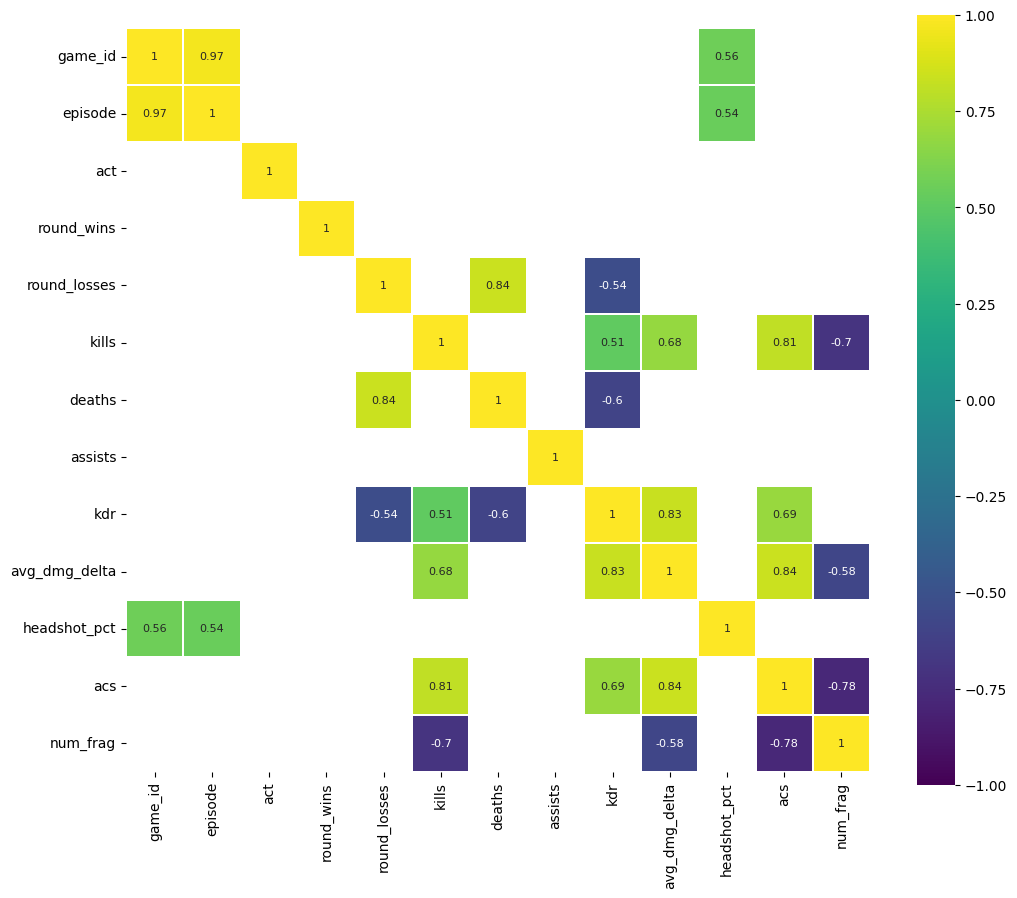

In [ ]:
data_num = data.select_dtypes(include = ['float64', 'int64']) # выбираем только числовые признаки
corr = data_num.drop('avg_dmg', axis=1).corr()
plt.figure(figsize=(12, 10))

sns.heatmap(corr[(corr >= 0.5) | (corr <= -0.5)],
            cmap='viridis', vmax=1.0, vmin=-1.0, linewidths=0.1,
            annot=True, annot_kws={"size": 8}, square=True);

этот код выбирает только числовые признаки из DataFrame, вычисляет корреляционную матрицу и визуализирует ее в виде тепловой карты (heatmap). Ячейки с насыщенным цветом (близкие к 1 или -1) указывают на сильную корреляцию.

In [ ]:
data_num = data.select_dtypes(include = ['float64', 'int64']) # выбираем только числовые признаки
data_num.head()

,game_id,episode,act,round_wins,round_losses,kills,deaths,assists,kdr,avg_dmg_delta,headshot_pct,avg_dmg,acs,num_frag
0,1,6,2,5,13,8,15,4,0.5,-61,3,76,125,3
1,2,6,2,4,13,3,15,2,0.2,-124,22,42,59,5
2,3,6,2,13,4,7,12,7,0.6,-46,2,87,132,5
3,4,6,2,9,13,18,12,10,1.5,23,14,137,230,2
4,5,6,2,1,13,6,14,3,0.4,-75,7,90,146,4


In [ ]:
corr_data = data_num.corr()['avg_dmg'][:-1]
correlated_features_list = corr_data[abs(corr_data) > 0.2].sort_values(ascending=False)
print("There are {} strongly values with SalePrice:\n{}".format(len(correlated_features_list),
                                                                          correlated_features_list))

There are 5 strongly values with SalePrice:
avg_dmg          1.000000
acs              0.964043
avg_dmg_delta    0.857952
kills            0.776079
kdr              0.650883
Name: avg_dmg, dtype: float64


этот код вычисляет коэффициенты корреляции всех числовых признаков с признаком 'avg_dmg' и отбирает те, чья абсолютная корреляция превышает 0.2. Показаные признаки сильно коррелируют с 'avg_dmg', что полезно для отбора признаков.

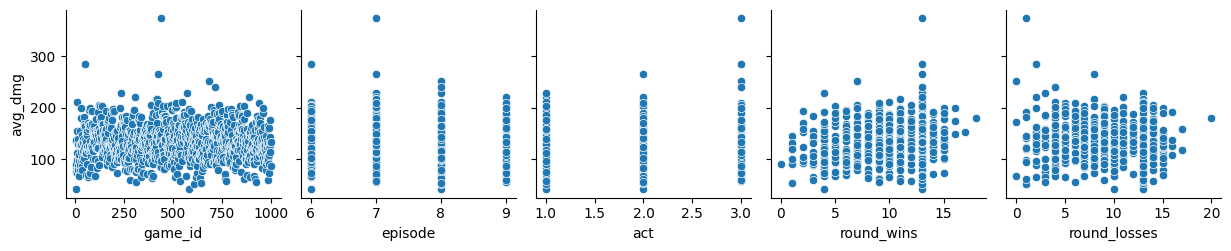

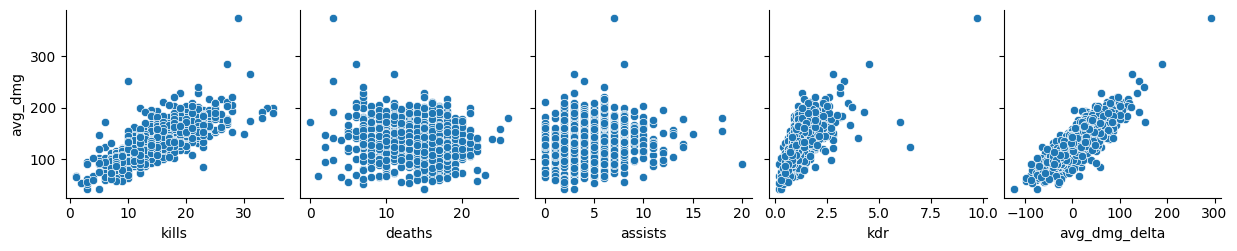

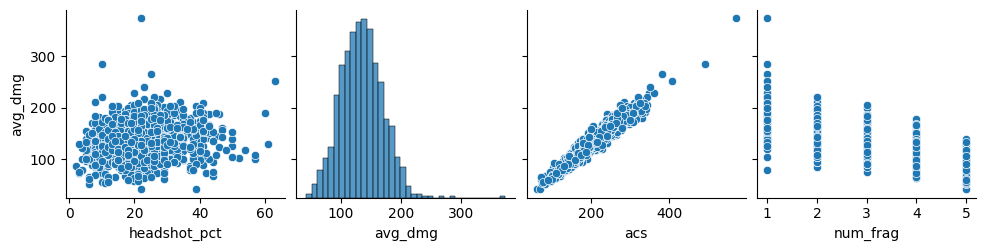

In [ ]:
for i in range(0, len(data_num.columns), 5):
    sns.pairplot(data=data_num,
                 x_vars=data_num.columns[i:i+5],
                 y_vars=['avg_dmg'])

этот код строит серию диаграмм рассеяния (pairplot) для каждой группы из 5 числовых признаков относительно признака 'avg_dmg'. Эти графики помогают визуально оценить характер связи между 'avg_dmg' и другими числовыми признаками

Заполнить пропуски во всех признаках (попробовать 3 различных способа).

1 способ

In [ ]:
mod_data.shape

(1000, 19)

In [ ]:
mod_data.dropna(axis = 0).shape # Отбрасываем строки


(950, 19)

In [ ]:
mod_data.dropna(axis = 1).shape # Отбрасываем столбцы

(1000, 14)

In [ ]:
mod_data.isna().sum()

,0
game_id,0
episode,0
act,0
rank,0
date,0
agent,0
map,0
outcome,0
round_wins,0
round_losses,0


этот код демонстрирует один из способов обработки пропусков: удаление строк, содержащих хотя бы одно пропущенное значение.


2 способ

In [ ]:
from sklearn.impute import SimpleImputer

simple_imp = SimpleImputer(missing_values = np.nan, strategy = 'constant', fill_value = 0) # заполняем 0
data_nan_zero = simple_imp.fit_transform(mod_data)
data_nan_zero = pd.DataFrame(data_nan_zero, columns = mod_data.columns)
data_nan_zero.head()

,game_id,episode,act,rank,date,agent,map,outcome,round_wins,round_losses,kills,deaths,assists,kdr,avg_dmg_delta,headshot_pct,avg_dmg,acs,num_frag
0,1,6,2,Placement,4/11/2023,Cypher,Ascent,Loss,5,13,8.0,15.0,4.0,0.5,-61,3,76.0,125,3
1,2,6,2,Placement,4/12/2023,Cypher,Icebox,Loss,4,13,3.0,15.0,2.0,0.2,-124,22,42.0,59,5
2,3,6,2,Placement,4/15/2023,KAY/O,Lotus,Win,13,4,7.0,12.0,7.0,0.6,-46,2,87.0,132,5
3,4,6,2,Placement,4/15/2023,Brimstone,Ascent,Loss,9,13,18.0,12.0,10.0,0,23,14,137.0,230,2
4,5,6,2,Placement,4/15/2023,Cypher,Haven,Loss,1,13,6.0,14.0,3.0,0.4,-75,7,90.0,146,4


<Axes: xlabel='deaths', ylabel='Count'>

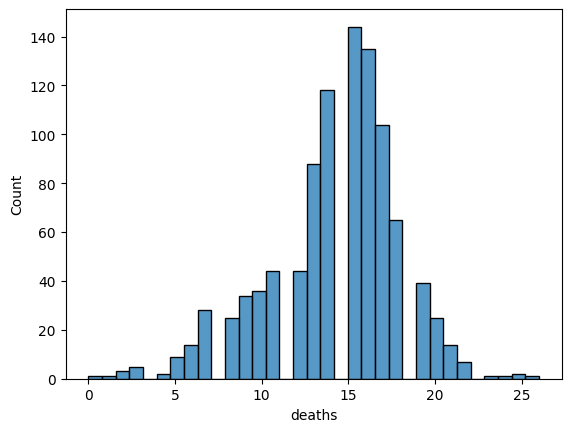

In [ ]:
sns.histplot(data = mod_data, x = 'deaths')

<Axes: xlabel='deaths', ylabel='Count'>

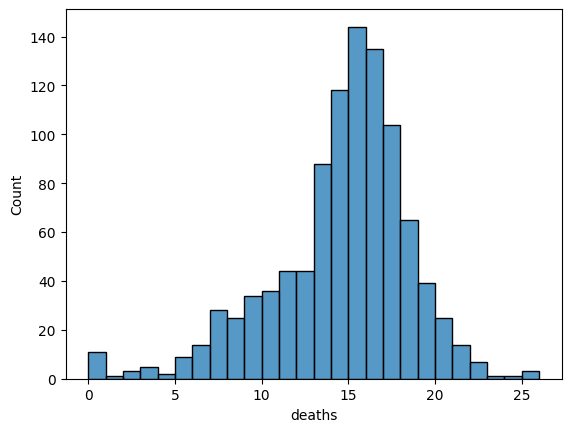

In [ ]:
sns.histplot(data = data_nan_zero, x = 'deaths')

In [ ]:
data_nan_zero.isna().sum()

,0
game_id,0
episode,0
act,0
rank,0
date,0
agent,0
map,0
outcome,0
round_wins,0
round_losses,0


этот код демонстрирует второй способ обработки пропусков: удаление столбцов, содержащих хотя бы одно пропущенное значение.

3 способ

In [ ]:
from sklearn.impute import SimpleImputer

# Выбираем только числовые столбцы
mod_data_num = mod_data.select_dtypes(include=np.number)
mod_data_cat = mod_data.select_dtypes(exclude=np.number)
simple_imp_mean = SimpleImputer(missing_values = np.nan, strategy = 'mean')
data_nan_mean_imputed = simple_imp_mean.fit_transform(mod_data_num)
data_nan_mean_imputed = pd.DataFrame(data_nan_mean_imputed, columns=mod_data_num.columns, index=mod_data_num.index)
data_nan_mean = pd.concat([mod_data_cat, data_nan_mean_imputed], axis=1)
data_nan_mean.head()

,rank,date,agent,map,outcome,game_id,episode,act,round_wins,round_losses,kills,deaths,assists,kdr,avg_dmg_delta,headshot_pct,avg_dmg,acs,num_frag
0,Placement,4/11/2023,Cypher,Ascent,Loss,1.0,6.0,2.0,5.0,13.0,8.0,15.0,4.0,0.500000,-61.0,3.0,76.0,125.0,3.0
1,Placement,4/12/2023,Cypher,Icebox,Loss,2.0,6.0,2.0,4.0,13.0,3.0,15.0,2.0,0.200000,-124.0,22.0,42.0,59.0,5.0
2,Placement,4/15/2023,KAY/O,Lotus,Win,3.0,6.0,2.0,13.0,4.0,7.0,12.0,7.0,0.600000,-46.0,2.0,87.0,132.0,5.0
3,Placement,4/15/2023,Brimstone,Ascent,Loss,4.0,6.0,2.0,9.0,13.0,18.0,12.0,10.0,1.177374,23.0,14.0,137.0,230.0,2.0
4,Placement,4/15/2023,Cypher,Haven,Loss,5.0,6.0,2.0,1.0,13.0,6.0,14.0,3.0,0.400000,-75.0,7.0,90.0,146.0,4.0


<Axes: xlabel='deaths', ylabel='Count'>

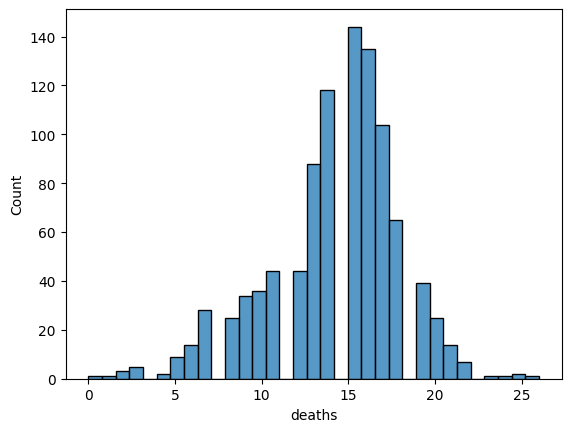

In [ ]:
sns.histplot(data = mod_data, x = 'deaths')

<Axes: xlabel='deaths', ylabel='Count'>

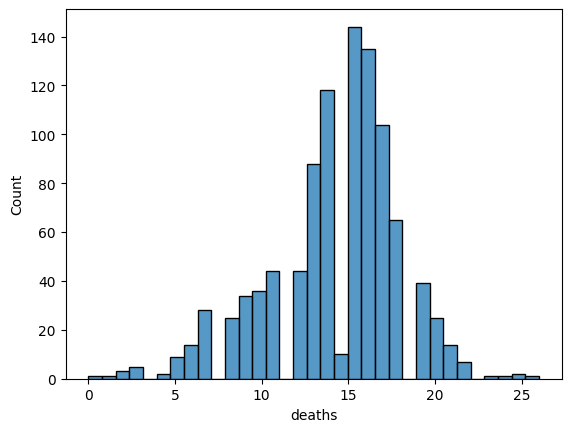

In [ ]:
sns.histplot(data = data_nan_mean, x = 'deaths')

In [ ]:
data_nan_mean.isna().sum()

,0
rank,0
date,0
agent,0
map,0
outcome,0
game_id,0
episode,0
act,0
round_wins,0
round_losses,0


In [ ]:
data_inter_linear = mod_data.interpolate(method='linear')#.fillna(0)

data_inter_linear.head()

,game_id,episode,act,rank,date,agent,map,outcome,round_wins,round_losses,kills,deaths,assists,kdr,avg_dmg_delta,headshot_pct,avg_dmg,acs,num_frag
0,1,6,2,Placement,4/11/2023,Cypher,Ascent,Loss,5,13,8.0,15.0,4.0,0.5,-61,3,76.0,125,3
1,2,6,2,Placement,4/12/2023,Cypher,Icebox,Loss,4,13,3.0,15.0,2.0,0.2,-124,22,42.0,59,5
2,3,6,2,Placement,4/15/2023,KAY/O,Lotus,Win,13,4,7.0,12.0,7.0,0.6,-46,2,87.0,132,5
3,4,6,2,Placement,4/15/2023,Brimstone,Ascent,Loss,9,13,18.0,12.0,10.0,0.5,23,14,137.0,230,2
4,5,6,2,Placement,4/15/2023,Cypher,Haven,Loss,1,13,6.0,14.0,3.0,0.4,-75,7,90.0,146,4


In [ ]:
data_inter_linear.isna().sum()

,0
game_id,0
episode,0
act,0
rank,0
date,0
agent,0
map,0
outcome,0
round_wins,0
round_losses,0


этот код демонстрирует третий способ заполнения пропусков: он использует линейную интерполяцию для оценки и заполнения пропущенных значений, основываясь на соседних данных.

Оценить наличие выбросов (z-оценка или ящик с усами), удалить выбросы

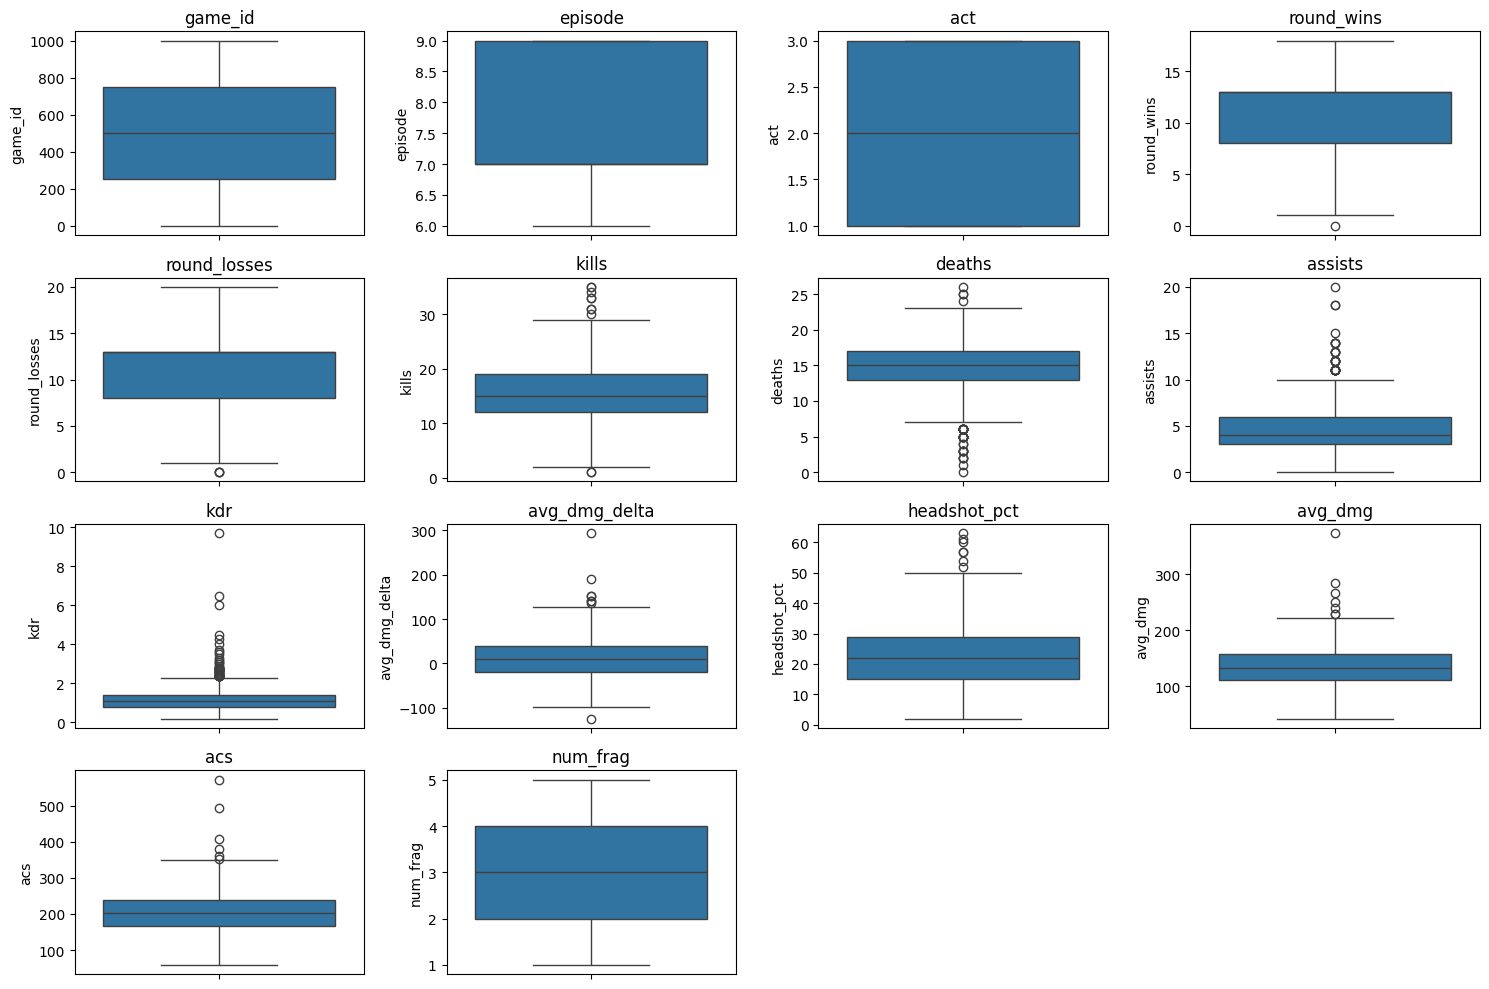

In [ ]:
# Оценка наличия выбросов с использованием boxplot
numerical_cols = mod_data.select_dtypes(include=np.number).columns

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i + 1)
    sns.boxplot(y=mod_data[col])
    plt.title(col)

plt.tight_layout()
plt.show()

этот код строит ящиковые диаграммы (boxplot) для всех числовых столбцов в DataFrame mod_data, что позволяет визуально оценить распределение данных и наличие выбросов. Точки за пределами 'усов' на boxplot'ах являются потенциальными выбросами.

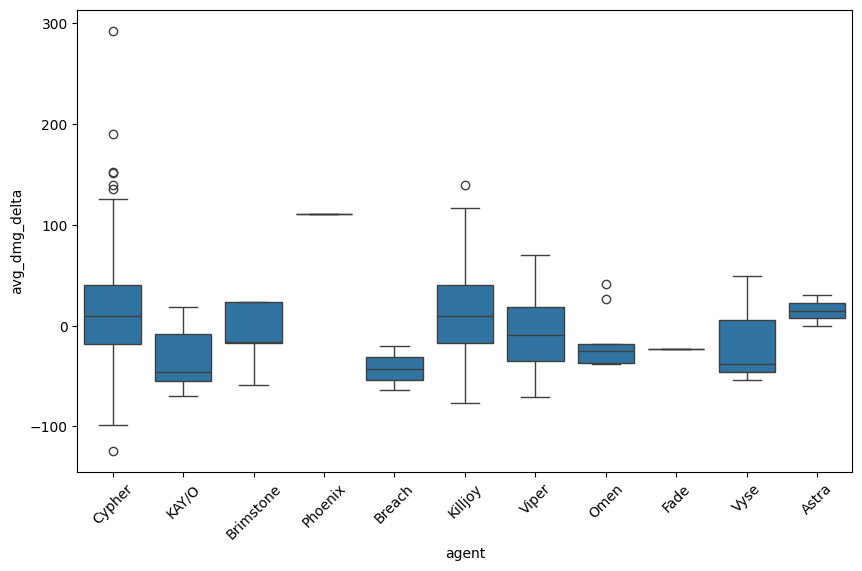

In [ ]:
plt.figure(figsize = (10, 6))
ax = sns.boxplot(x='agent', y='avg_dmg_delta', data=mod_data)
plt.setp(ax.artists, alpha=.5, linewidth=2, edgecolor="k")
plt.xticks(rotation=45);

этот код строит ящиковый график, показывающий распределение 'avg_dmg_delta' (изменения среднего урона) для каждого 'agent'. Этот график помогает выявить различия в 'avg_dmg_delta' между агентами и обнаружить выбросы в производительности каждого агента.

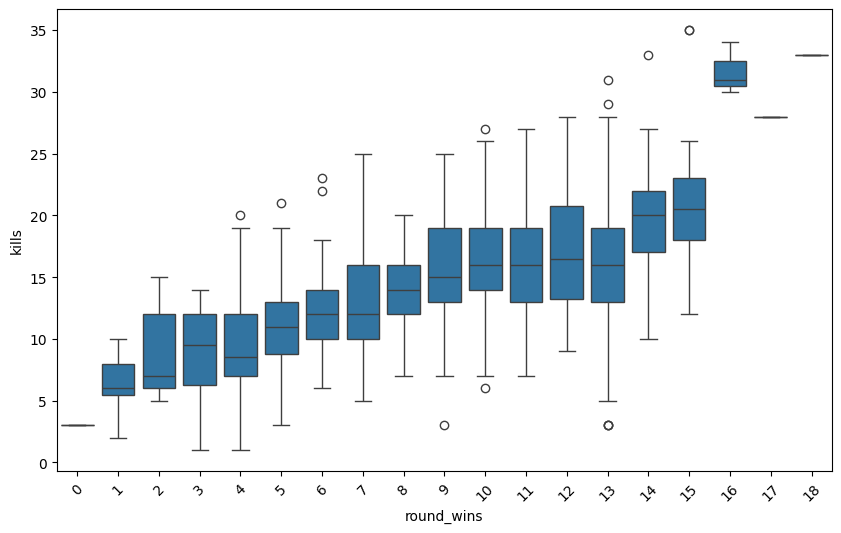

In [ ]:
plt.figure(figsize = (10, 6))
ax = sns.boxplot(x='round_wins', y='kills', data=data)
plt.setp(ax.artists, alpha=.5, linewidth=2, edgecolor="k")
plt.xticks(rotation=45);

Этот код строит ящиковый график, показывающий распределение количества убийств ('kills') в зависимости от количества выигранных раундов ('round_wins'). Этот график позволяет увидеть, как количество убийств варьируется в зависимости от побед в раундах, а также выявить необычно высокие или низкие значения.

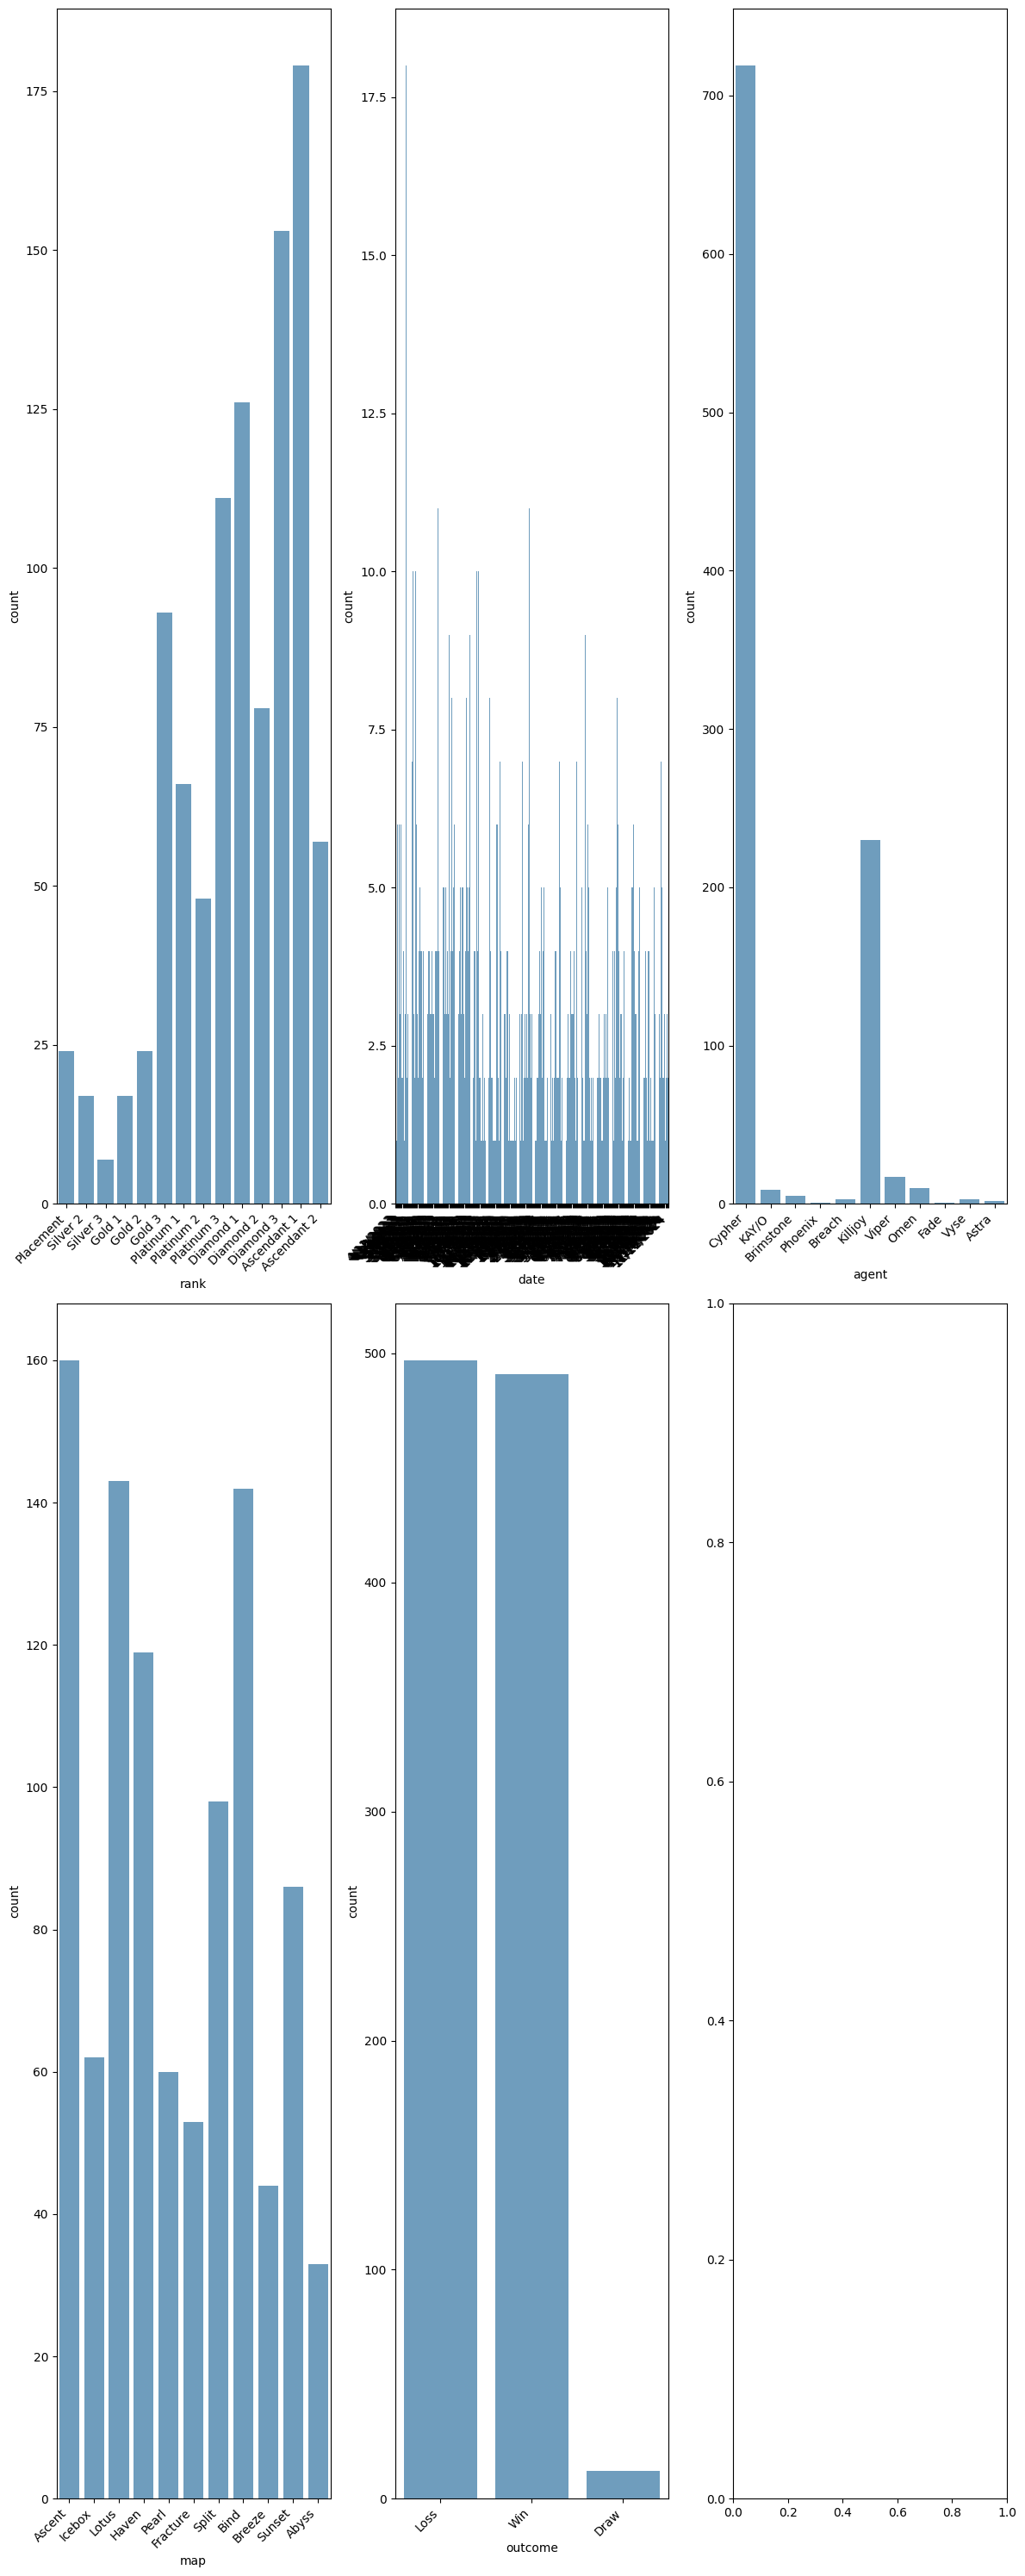

In [ ]:
df_categ = data_nan_mean.select_dtypes(exclude=np.number) # Определяем категориальные признаки

fig, axes = plt.subplots(round(len(df_categ.columns) / 3), 3, figsize=(12, 30))

# Flatten the axes array for easier iteration if it's 2D
axes = axes.flatten()

for i, ax in enumerate(fig.axes):
    if i < len(df_categ.columns):
        sns.countplot(x=df_categ.columns[i], alpha=0.7, data=df_categ, ax=ax)
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right') # Rotate and align x-axis labels

fig.tight_layout()

этот код генерирует несколько гистограмм частотности (countplot) для всех категориальных признаков из DataFrame data_nan_mean. Эти графики показывают распределение уникальных значений в каждой категориальной переменной, позволяя оценить их частоту.

In [ ]:
from scipy.stats import zscore

# Выбираем только числовые столбцы
numerical_cols = mod_data.select_dtypes(include=np.number).columns

# Рассчитываем Z-оценку для числовых столбцов
z_scores = np.abs(zscore(mod_data[numerical_cols].dropna()))

# Устанавливаем порог для Z-оценки
threshold = 3

# Определяем индексы строк с выбросами
outlier_indices = np.where(z_scores > threshold)

# Удаляем строки с выбросами из копии DataFrame
data_no_outliers_zscore = mod_data.drop(mod_data.dropna().iloc[outlier_indices[0]].index)

print(f"Original shape: {mod_data.shape}")
print(f"Shape after removing outliers using Z-score (threshold={threshold}): {data_no_outliers_zscore.shape}")

Original shape: (1000, 19)
Shape after removing outliers using Z-score (threshold=3): (962, 19)


этот код использует метод Z-оценки для выявления и удаления выбросов из числовых столбцов DataFrame mod_data. Выбросы определяются как значения с Z-оценкой более 3. Было удалено 37 строк.

Z-оценка это показатель насколько отличается от среднего группы данных.
Z-оценка устанавливает порог в 3, так как выбросы находятся +-3 отклонениях от стандартного признака.

Закодировать все категориальные переменные (попробовать 3 различных способа).

In [ ]:
data_f = data_nan_mean.copy() # Инициализируем data_f с данными после заполнения пропусков
data_f['rank'].value_counts()

,count
rank,
Ascendant 1,179
Diamond 3,153
Diamond 1,126
Platinum 3,111
Gold 3,93
Diamond 2,78
Platinum 1,66
Ascendant 2,57
Platinum 2,48


этот код инициализирует data_f копией очищенного DataFrame data_nan_mean и выводит количество вхождений для каждой уникальной категории в столбце 'rank'. 'Ascendant 1' самый распостраненный ранг.

In [ ]:
data_f['map'].value_counts()

,count
map,
Ascent,160
Lotus,143
Bind,142
Haven,119
Split,98
Sunset,86
Icebox,62
Pearl,60
Fracture,53


этот код выводит количество вхождений для каждой уникальной категории в столбце 'map'. 'Ascent' самая распостраненая карта.

In [ ]:
feature = {"map": {"Ascent": 1, "Lotus": 2, "Bind": 3, "Haven": 4, "Split": 5, "Sunset": 6, "Icebox": 7, "Pearl": 8, "Fracture": 9, "Breeze": 10, "Abyss": 11}}
data_encode = data_f.replace(feature)
data_encode['map'].value_counts()

,count
map,
1,160
2,143
3,142
4,119
5,98
6,86
7,62
8,60
9,53


этот код демонстрирует ручное кодирование категориальной переменной 'map' путем сопоставления каждого уникального названия карты с числовым значением из словаря

In [ ]:
data_f["map"] = data_f["map"].astype('category')
data_f["map cat"] = data_f["map"].cat.codes
data_f['map cat'].value_counts()

,count
map cat,
1,160
7,143
2,142
5,119
9,98
10,86
6,62
8,60
4,53


этот код демонстрирует кодирование категориальной переменной 'map' с использованием метода Label Encoding (преобразование категорий в числовые коды) с помощью .astype('category').cat.codes

In [ ]:
data_f = data_f.drop('map cat', axis = 1)

этот код удаляет временный столбец 'map cat', который был создан в процессе Label Encoding.

In [ ]:
pd.get_dummies(data_f, columns=["rank"]).head()

,date,agent,map,outcome,game_id,episode,act,round_wins,round_losses,kills,...,rank_Diamond 3,rank_Gold 1,rank_Gold 2,rank_Gold 3,rank_Placement,rank_Platinum 1,rank_Platinum 2,rank_Platinum 3,rank_Silver 2,rank_Silver 3
0,4/11/2023,Cypher,Ascent,Loss,1.0,6.0,2.0,5.0,13.0,8.0,...,False,False,False,False,True,False,False,False,False,False
1,4/12/2023,Cypher,Icebox,Loss,2.0,6.0,2.0,4.0,13.0,3.0,...,False,False,False,False,True,False,False,False,False,False
2,4/15/2023,KAY/O,Lotus,Win,3.0,6.0,2.0,13.0,4.0,7.0,...,False,False,False,False,True,False,False,False,False,False
3,4/15/2023,Brimstone,Ascent,Loss,4.0,6.0,2.0,9.0,13.0,18.0,...,False,False,False,False,True,False,False,False,False,False
4,4/15/2023,Cypher,Haven,Loss,5.0,6.0,2.0,1.0,13.0,6.0,...,False,False,False,False,True,False,False,False,False,False


этот код демонстрирует One-Hot Encoding для категориальной переменной 'rank' с помощью pd.get_dummies(). Это создает новые бинарные столбцы для каждой уникальной категории ранга. One-Hot Encoding преобразует категориальные данные в формат, подходящий для большинства моделей машинного обучения.

In [ ]:
# продвинутый вариант, для него установим библиотеку
!pip3 install category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 2.7 MB/s eta 0:00:00


этот код устанавливает библиотеку category_encoders, которая предоставляет различные продвинутые методы кодирования категориальных признаков.

In [ ]:
import category_encoders as ce

In [ ]:
data_tmp = data_f.copy()
encoder = ce.BackwardDifferenceEncoder(cols=["agent"])
encoder.fit(data_tmp, verbose=1)

BackwardDifferenceEncoder(cols=['agent'],
                          mapping=[{'col': 'agent',
                                    'mapping':       agent_0   agent_1   agent_2   agent_3   agent_4   agent_5   agent_6  \
 1  -0.909091 -0.818182 -0.727273 -0.636364 -0.545455 -0.454545 -0.363636   
 2   0.090909 -0.818182 -0.727273 -0.636364 -0.545455 -0.454545 -0.363636   
 3   0.090909  0.181818 -0.727273 -0.636364 -0.545455 -0.454545 -0.363636   
 4   0.090909  0.181818  0.272727 -0.636364 -0...
 1  -0.272727 -0.181818 -0.090909  
 2  -0.272727 -0.181818 -0.090909  
 3  -0.272727 -0.181818 -0.090909  
 4  -0.272727 -0.181818 -0.090909  
 5  -0.272727 -0.181818 -0.090909  
 6  -0.272727 -0.181818 -0.090909  
 7  -0.272727 -0.181818 -0.090909  
 8  -0.272727 -0.181818 -0.090909  
 9   0.727273 -0.181818 -0.090909  
 10  0.727273  0.818182 -0.090909  
 11  0.727273  0.818182  0.909091  
-1   0.000000  0.000000  0.000000  
-2   0.000000  0.000000  0.000000  }])

этот код инициализирует и 'обучает' (fit) BackwardDifferenceEncoder для столбца 'agent'. Этот метод кодирования создает новые числовые признаки, которые представляют разницу между средним значением целевой переменной для категории и средним значением целевой переменной для предыдущей категории.

In [ ]:
data_cat_enc = encoder.fit_transform(data_tmp, verbose=1) # набор данных после кодирования категориальных признаков
data_cat_enc = data_cat_enc.drop('map', axis = 1)
data_cat_enc.head()

,rank,date,agent_0,agent_1,agent_2,agent_3,agent_4,agent_5,agent_6,agent_7,...,round_losses,kills,deaths,assists,kdr,avg_dmg_delta,headshot_pct,avg_dmg,acs,num_frag
0,Placement,4/11/2023,-0.909091,-0.818182,-0.727273,-0.636364,-0.545455,-0.454545,-0.363636,-0.272727,...,13.0,8.0,15.000000,4.0,0.5,-61.0,3.0,76.0,125.0,3.0
1,Placement,4/12/2023,-0.909091,-0.818182,-0.727273,-0.636364,-0.545455,-0.454545,-0.363636,-0.272727,...,13.0,3.0,14.273737,2.0,0.2,-124.0,22.0,42.0,59.0,5.0
2,Placement,4/15/2023,0.090909,-0.818182,-0.727273,-0.636364,-0.545455,-0.454545,-0.363636,-0.272727,...,4.0,7.0,12.000000,7.0,0.6,-46.0,2.0,87.0,132.0,5.0
3,Placement,4/15/2023,0.090909,0.181818,-0.727273,-0.636364,-0.545455,-0.454545,-0.363636,-0.272727,...,13.0,18.0,12.000000,10.0,1.5,23.0,14.0,137.0,230.0,2.0
4,Placement,4/15/2023,-0.909091,-0.818182,-0.727273,-0.636364,-0.545455,-0.454545,-0.363636,-0.272727,...,13.0,6.0,14.000000,3.0,0.4,-75.0,7.0,90.0,146.0,4.0


этот код применяет обученный BackwardDifferenceEncoder для преобразования категориальной переменной 'agent' в несколько числовых столбцов с использованием обратного разностного кодирования.

Анализ методом главных компонент (PCA) на вашем датасете

Используем 'rank' в качестве целевой переменной для визуализации.
Размерность числовых данных для PCA: (1000, 14)

Объясненная дисперсия компонент:
Компонента 1: 0.354 (0.354 кумулятивно)
Компонента 2: 0.183 (0.537 кумулятивно)
Компонента 3: 0.159 (0.695 кумулятивно)
Компонента 4: 0.102 (0.797 кумулятивно)
Компонента 5: 0.064 (0.862 кумулятивно)
Компонента 6: 0.047 (0.909 кумулятивно)
Компонента 7: 0.036 (0.945 кумулятивно)
Компонента 8: 0.020 (0.965 кумулятивно)
Компонента 9: 0.016 (0.981 кумулятивно)
Компонента 10: 0.009 (0.990 кумулятивно)
Компонента 11: 0.005 (0.996 кумулятивно)
Компонента 12: 0.002 (0.998 кумулятивно)
Компонента 13: 0.001 (0.999 кумулятивно)
Компонента 14: 0.001 (1.000 кумулятивно)


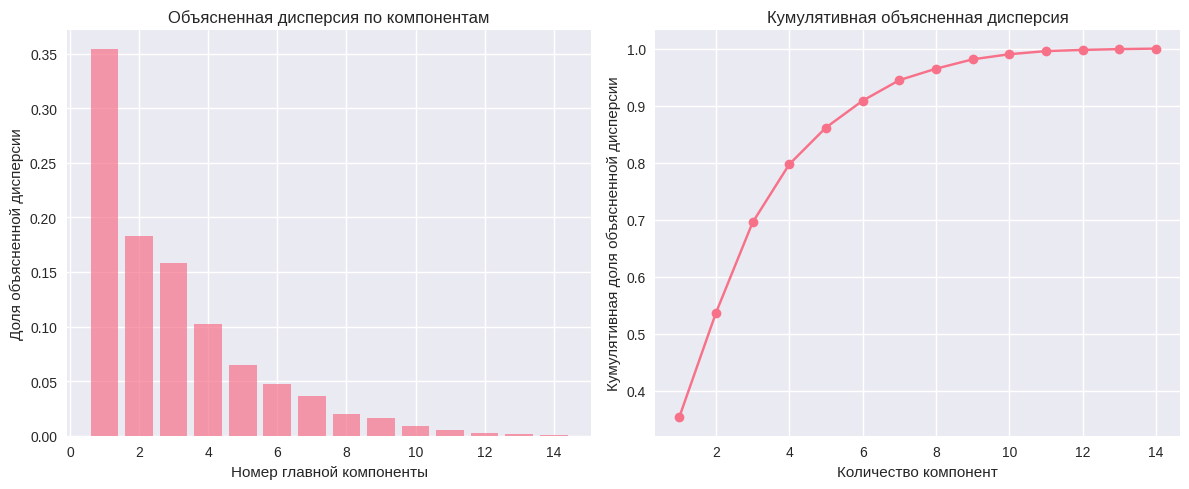


Визуализация в 2D пространстве


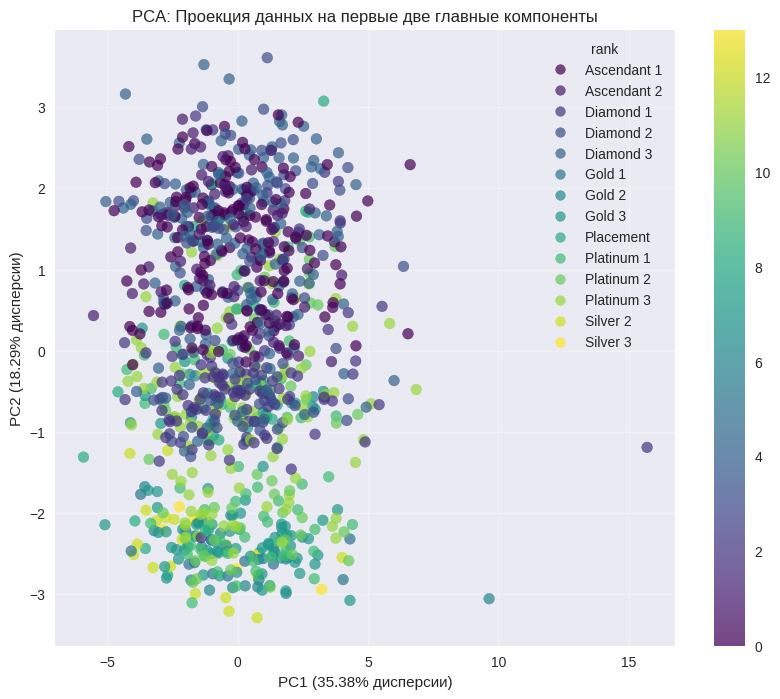


Анализ нагрузок компонент (первых 2):
Нагрузки:
                    PC1       PC2
game_id        0.012753  0.922629
episode        0.006805  0.950431
act            0.008009 -0.427874
round_wins     0.406140 -0.095135
round_losses  -0.360952  0.017765
kills          0.801918 -0.055210
deaths        -0.348635 -0.098877
assists        0.097709 -0.267999
kdr            0.838256 -0.004907
avg_dmg_delta  0.950654  0.023009
headshot_pct   0.210253  0.724964
avg_dmg        0.914897 -0.026762
acs            0.935560 -0.065573
num_frag      -0.725325  0.024987


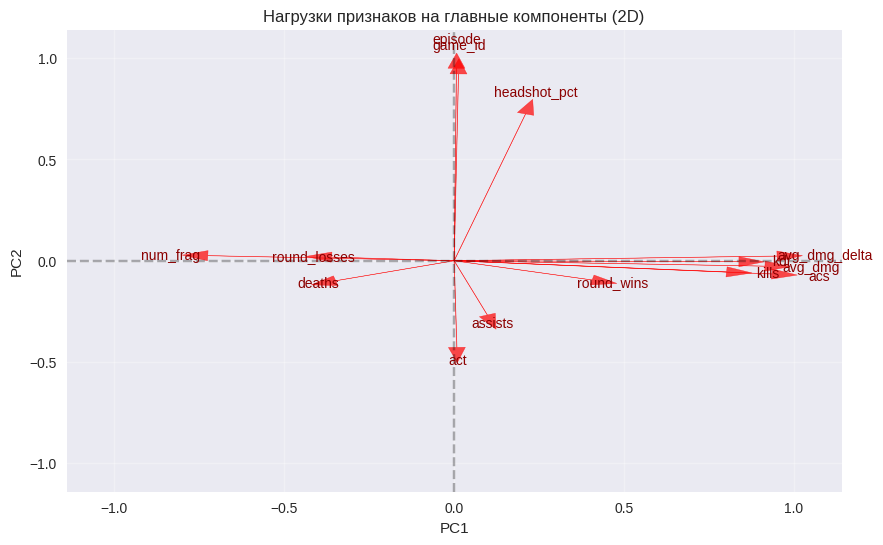


Сводка по PCA анализу:
Исходная размерность (числовых признаков): 14
Сжатая размерность (2D): 2 компоненты
Сохраненная дисперсия (2 компонент): 53.68%
Потерянная дисперсия (2 компонент): 46.32%


In [ ]:
# Установка дополнительных библиотек (если нужны)
# !pip install plotly

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelEncoder
# from sklearn.datasets import load_iris, load_wine # Удаляем загрузку примеров датасетов
import plotly.express as px

# Для красивого отображения графиков
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("Анализ методом главных компонент (PCA) на вашем датасете")

# Используем ваш датасет mod_data (или data_nan_mean, data_median_filled, data_mode_filled)
# Предполагается, что пропуски уже были заполнены в предыдущих шагах.
# Используем data_nan_mean как пример датасета с заполненными пропусками.
# Если у вас другой датасет с заполненными пропусками, измените имя переменной.
data_for_pca = data_nan_mean.copy()

# Выбираем только числовые столбцы для PCA
numerical_cols = data_for_pca.select_dtypes(include=np.number).columns
X = data_for_pca[numerical_cols].values

# Выбираем категориальный признак в качестве "целевой" переменной для визуализации
# Вы можете выбрать другой категориальный столбец, например 'agent' или 'map'
target_column_name = 'rank'
if target_column_name in data_for_pca.columns:
    y_categorical = data_for_pca[target_column_name]
    # Кодируем категориальную целевую переменную для визуализации
    le = LabelEncoder()
    y = le.fit_transform(y_categorical)
    target_names = le.classes_ # Получаем имена классов
    print(f"\nИспользуем '{target_column_name}' в качестве целевой переменной для визуализации.")
else:
    print(f"\nСтолбец '{target_column_name}' не найден в датасете. Визуализация по целевой переменной будет недоступна.")
    y = None
    target_names = None


print(f"Размерность числовых данных для PCA: {X.shape}")

# Стандартизация данных

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Применение PCA

pca = PCA() # Сначала обучаем PCA на всех компонентах для анализа объясненной дисперсии
X_pca = pca.fit_transform(X_scaled)

# Анализ объясненной дисперсии
print("\nОбъясненная дисперсия компонент:")
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

for i, (var, cum_var) in enumerate(zip(explained_variance, cumulative_variance)):
    print(f"Компонента {i+1}: {var:.3f} ({cum_var:.3f} кумулятивно)")

# Визуализация объясненной дисперсии
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.bar(range(1, len(explained_variance) + 1), explained_variance, alpha=0.7)
plt.xlabel('Номер главной компоненты')
plt.ylabel('Доля объясненной дисперсии')
plt.title('Объясненная дисперсия по компонентам')

plt.subplot(1, 2, 2)
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, 'o-')
plt.xlabel('Количество компонент')
plt.ylabel('Кумулятивная доля объясненной дисперсии')
plt.title('Кумулятивная объясненная дисперсия')
plt.grid(True)

plt.tight_layout()
plt.show()

# Применяем PCA для сжатия до 2 или 3 компонент
n_components_to_visualize = 2 # Выберите 2 или 3
if X_pca.shape[1] < n_components_to_visualize:
    n_components_to_visualize = X_pca.shape[1]
    print(f"\nДоступно только {n_components_to_visualize} компоненты для визуализации.")

pca_viz = PCA(n_components=n_components_to_visualize)
X_pca_viz = pca_viz.fit_transform(X_scaled)

# Визуализация в 2D или 3D
if n_components_to_visualize == 2:
    print("\nВизуализация в 2D пространстве")
    plt.figure(figsize=(10, 8))

    # Создаем DataFrame для удобства
    pca_df_viz = pd.DataFrame({
        'PC1': X_pca_viz[:, 0],
        'PC2': X_pca_viz[:, 1],
        'target': y # Используем закодированную целевую переменную
    })

    scatter = plt.scatter(X_pca_viz[:, 0], X_pca_viz[:, 1], c=y, cmap='viridis', alpha=0.7, s=60)
    plt.colorbar(scatter)
    plt.xlabel(f'PC1 ({pca_viz.explained_variance_ratio_[0]:.2%} дисперсии)')
    plt.ylabel(f'PC2 ({pca_viz.explained_variance_ratio_[1]:.2%} дисперсии)')
    plt.title('PCA: Проекция данных на первые две главные компоненты')

    # Добавляем легенду если target_names доступны
    if target_names is not None:
        handles, labels = scatter.legend_elements()
        # Создаем словарь для сопоставления числовых меток и имен классов
        label_dict = {i: name for i, name in enumerate(target_names)}
        # Обновляем метки легенды
        legend_labels = [label_dict[int(label.split('{')[1].split('}')[0])] for label in labels]
        plt.legend(handles, legend_labels, title=target_column_name)


    plt.grid(True, alpha=0.3)
    plt.show()

elif n_components_to_visualize == 3:
    print("\nВизуализация в 3D пространстве")

    # Используем plotly для интерактивной 3D визуализации
    pca_df_viz = pd.DataFrame({
        'PC1': X_pca_viz[:, 0],
        'PC2': X_pca_viz[:, 1],
        'PC3': X_pca_viz[:, 2],
        'target': y # Используем закодированную целевую переменную
    })

    if target_names is not None:
        pca_df_viz['class'] = y_categorical # Используем исходные имена классов для plotly
        fig = px.scatter_3d(pca_df_viz, x='PC1', y='PC2', z='PC3',
                           color='class',
                           title='PCA: 3D визуализация главных компонент',
                           labels={'PC1': f'PC1 ({pca_viz.explained_variance_ratio_[0]:.2%})',
                                 'PC2': f'PC2 ({pca_viz.explained_variance_ratio_[1]:.2%})',
                                 'PC3': f'PC3 ({pca_viz.explained_variance_ratio_[2]:.2%})'})
    else:
         fig = px.scatter_3d(pca_df_viz, x='PC1', y='PC2', z='PC3',
                           color='target', # Визуализация по числовым меткам если имена классов недоступны
                           title='PCA: 3D визуализация главных компонент')

    fig.show()

# Анализ нагрузок (вклад исходных признаков в компоненты) - для первых 2 или 3 компонент
print(f"\nАнализ нагрузок компонент (первых {n_components_to_visualize}):")
loadings = pca_viz.components_.T * np.sqrt(pca_viz.explained_variance_)

loadings_df = pd.DataFrame(loadings[:, :n_components_to_visualize],
                          columns=[f'PC{i+1}' for i in range(n_components_to_visualize)],
                          index=numerical_cols) # Используем имена числовых столбцов

print("Нагрузки:")
print(loadings_df)

# Визуализация нагрузок (только для 2D)
if n_components_to_visualize == 2:
    plt.figure(figsize=(10, 6))
    for i, feature in enumerate(numerical_cols):
        plt.arrow(0, 0, loadings[i, 0], loadings[i, 1],
                  color='r', alpha=0.7, head_width=0.05)
        plt.text(loadings[i, 0]*1.15, loadings[i, 1]*1.15,
                 feature, color='darkred', ha='center', va='center')

    # Автоматическое определение пределов графика на основе нагрузок
    max_loading = np.max(np.abs(loadings[:, :2])) * 1.2
    plt.xlim(-max_loading, max_loading)
    plt.ylim(-max_loading, max_loading)

    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.title('Нагрузки признаков на главные компоненты (2D)')
    plt.grid(True, alpha=0.3)
    plt.axhline(y=0, color='k', linestyle='--', alpha=0.3)
    plt.axvline(x=0, color='k', linestyle='--', alpha=0.3)
    plt.show()


# Сводка по результатам PCA
print("\nСводка по PCA анализу:")
print(f"Исходная размерность (числовых признаков): {X.shape[1]}")
print(f"Сжатая размерность ({n_components_to_visualize}D): {n_components_to_visualize} компоненты")
print(f"Сохраненная дисперсия ({n_components_to_visualize} компонент): {cumulative_variance[n_components_to_visualize-1]:.2%}")
print(f"Потерянная дисперсия ({n_components_to_visualize} компонент): {1 - cumulative_variance[n_components_to_visualize-1]:.2%}")

# Дополнительная визуализация: pairplot для первых нескольких компонент (если больше 2 компонент)
if n_components_to_visualize > 2:
    print("\nPairplot главных компонент...")
    pca_components_to_show = min(4, X_pca_viz.shape[1])
    pca_df_pair = pd.DataFrame(X_pca_viz[:, :pca_components_to_show],
                              columns=[f'PC{i+1}' for i in range(pca_components_to_show)])

    if target_names is not None:
        pca_df_pair[target_column_name] = y_categorical # Используем исходные имена классов
        g = sns.pairplot(pca_df_pair, hue=target_column_name, palette='viridis',
                        diag_kind='kde', plot_kws={'alpha': 0.7})
    else:
        # Pairplot без цветового разделения, если нет целевой переменной
        g = sns.pairplot(pca_df_pair, diag_kind='kde', plot_kws={'alpha': 0.7})


    g.fig.suptitle('Pairplot главных компонент', y=1.02)
    plt.show()

этот код выполняет анализ методом главных компонент (PCA) для сокращения размерности числовых признаков. Он включает в себя стандартизацию данных, расчет объясненной дисперсии и визуализацию данных в 2D или 3D пространстве главных компонент, а также анализ нагрузок признаков.
1. Графики объясненной дисперсии (Explained Variance Plots):

*   На первом графике (столбчатая диаграмма) показана доля объясненной дисперсии каждой отдельной главной компонентой. Вы можете видеть, что первая компонента объясняет наибольшую долю дисперсии (0.354 или 35.4%), вторая — следующую по величине (0.183 или 18.3%), и так далее по убыванию.

*   Второй график (кумулятивная кривая) показывает накопленную объясненную дисперсию. Это помогает определить, сколько главных компонент необходимо для сохранения заданного процента информации из исходного набора данных.

Чтобы сохранить, например, более 90% информации, потребуется около 6-7 главных компонент (6 компонент: 90.9%, 7 компонент: 94.5%). Таким образом, для сохранения большей части информации (например, 80-90%) вам потребуется от 4 до 7 главных компонент, что значительно меньше исходных 14 числовых признаков.

2. 2D Scatter Plot (Визуализация в 2D пространстве):

*   Этот график отображает данные, спроецированные на две первые главные компоненты (PC1 и PC2). Каждая точка на графике соответствует одному игровому матчу, а цвет точки соответствует рангу ('rank').

*   Цель такой визуализации – определить, формируют ли различные ранги отдельные кластеры в этом уменьшенном пространстве. Если точки одного цвета (одного ранга) группируются вместе и отделены от точек других цветов, это означает, что различия в числовых характеристиках, которые легли в основу PC1 и PC2, хорошо разделяют ранги.

В данном графике PCA успешно выделил признаки, по которым ранги отличаются.

3. Нагрузки признаков (Feature Loadings):

*   Нагрузки показывают, насколько сильно каждый исходный признак влияет на формирование каждой главной компоненты (то есть, как он с ней коррелирует). Чем больше абсолютное значение нагрузки, тем важнее признак для данной компоненты.

*  Для PC1 (Первая главная компонента):
    *   Наибольшие положительные нагрузки имеют avg_dmg_delta (0.95), acs (0.93), avg_dmg (0.91), kdr (0.84) и kills (0.80). Это указывает на то, что PC1 в основном отражает общую боевую эффективность игрока, связанную с нанесенным уроном, убийствами, коэффициентом убийств/смертей и боевым счётом.
    
    *   Признак num_frag имеет значительную отрицательную нагрузку (-0.72), что может указывать на обратную связь или на то, что эта компонента разделяет игроков по их роли и стилю игры.

*  Для PC2 (Вторая главная компонента):
    *  Наибольшие положительные нагрузки имеют episode (0.95) и game_id (0.92). Это означает, что PC2 в значительной степени связана с хронологическими или порядковыми аспектами данных.

    *  Также заметна нагрузка headshot_pct (0.72). Признак act имеет умеренную отрицательную нагрузку (-0.43). Это может говорить о том, что PC2 улавливает некоторые изменения в мета-данных со временем связанные с точностью стрельбы.

Таким образом, PCA позволил выделить две основные латентные переменные: первая компонента описывает боевую эффективность игрока, а вторая — скорее временные и стилевые характеристики игры.

